# NBA Playoff vs Regular Season Performance Analysis

## Research Question
This project analyzes whether NBA star players perform differently in the playoffs compared to the regular season.

The players included are:
- Anthony Edwards
- LeBron James
- Jayson Tatum
- Kevin Durant
- Stephen Curry
- Luka Doncic
- Nikola Jokic
- Giannis Antetokounmpo

This question matters because playoff basketball is often described as having higher pressure, tougher defense, and stronger competition. The goal is to test whether that difference shows up in field goal percentage.

## Hypothesis

**Null Hypothesis (H₀):**  
There is no difference in field goal percentage between playoff games and regular season games.

**Alternative Hypothesis (H₁):**  
NBA star players have a lower field goal percentage in playoff games compared to regular season games.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Loading and Combining Data

Game log data from Basketball Reference is imported for each player and season.  
Regular season and playoff game logs are combined into one dataset for analysis.

In [17]:
players = {
    "LeBron James": "Lebron James",
    "Anthony Edwards": "Anthony Edwards",
    "Jayson Tatum": "Jayson Tatum",
    "Kevin Durant": "Kevin Durant",
    "Stephen Curry": "Stephen Curry",
    "Luka Doncic": "Luka Doncic",
    "Nikola Jokic": "Nikola Jokic",
    "Giannis Antetokounmpo": "Giannis Antetokounmpo"
}

all_data = []

for player, folder in players.items():
    player_path = Path("NBA Reg-Playoffs") / folder
    
    regular_files = list(player_path.glob("*regular*.csv"))
    
    for file in regular_files:
        df = pd.read_csv(file, on_bad_lines="skip")
        season = file.stem.split("_")[-1]
        df["Player"] = player
        df["Season"] = season
        df["GameType"] = "Regular"
        all_data.append(df)
    
    playoff_files = list(player_path.glob("*playoff*.csv"))
    
    for file in playoff_files:
        df = pd.read_csv(file, on_bad_lines="skip")
        df["Player"] = player
        df["GameType"] = "Playoffs"
        all_data.append(df)

nba = pd.concat(all_data, ignore_index=True)

nba.head()

,Rk,Gcar,Gtm,Date,Team,Unnamed: 5,Opp,Result,GS,MP,...,BLK,TOV,PF,PTS,GmSc,+/-,Player,Season,GameType,{\rtf1\ansi\ansicpg1252\cocoartf2867
0,1.0,1311.0,1.0,2021-10-19,LAL,NaN,GSW,L 114-121,*,36:44,...,1,4,5,34,24.8,-2,LeBron James,2022,Regular,NaN
1,2.0,1312.0,2.0,2021-10-22,LAL,NaN,PHO,L 105-115,*,36:32,...,0,5,4,25,15.1,-6,LeBron James,2022,Regular,NaN
2,3.0,1313.0,3.0,2021-10-24,LAL,NaN,MEM,W 121-118,*,40:18,...,2,3,1,19,14.1,-1,LeBron James,2022,Regular,NaN
3,3.0,NaN,4.0,2021-10-26,LAL,@,SAS,W 125-121 (OT),Did Not Dress,Did Not Dress,...,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,LeBron James,2022,Regular,NaN
4,3.0,NaN,5.0,2021-10-27,LAL,@,OKC,L 115-123,Did Not Dress,Did Not Dress,...,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,LeBron James,2022,Regular,NaN


In [18]:
nba["Player"].value_counts()

Player
LeBron James             740
Kevin Durant             595
Jayson Tatum             547
Nikola Jokic             515
Giannis Antetokounmpo    505
Stephen Curry            504
Luka Doncic              468
Anthony Edwards          456
Name: count, dtype: int64

In [19]:
nba.groupby(["Player", "GameType"]).size()

Player                 GameType
Anthony Edwards        Playoffs     51
                       Regular     405
Giannis Antetokounmpo  Playoffs     92
                       Regular     413
Jayson Tatum           Playoffs     83
                       Regular     464
Kevin Durant           Playoffs    192
                       Regular     403
LeBron James           Playoffs    335
                       Regular     405
Luka Doncic            Playoffs     61
                       Regular     407
Nikola Jokic           Playoffs    110
                       Regular     405
Stephen Curry          Playoffs    176
                       Regular     328
dtype: int64

## Cleaning the Data

Rows where players were inactive, did not dress, or did not play are removed because those rows do not represent actual game performances.

FG% is converted into a numeric variable so summary statistics and statistical tests can be calculated.

In [20]:
nba_clean = nba[
    (nba["MP"].notna()) &
    (nba["MP"] != "Inactive") &
    (nba["MP"] != "Did Not Dress") &
    (nba["MP"] != "Did Not Play")
].copy()

nba_clean["FG%"] = pd.to_numeric(nba_clean["FG%"], errors="coerce")

print("Rows before cleaning:", len(nba))
print("Rows after cleaning:", len(nba_clean))
print(nba_clean["GameType"].value_counts())

Rows before cleaning: 4330
Rows after cleaning: 3694
GameType
Regular     2705
Playoffs     989
Name: count, dtype: int64


## Descriptive Statistics

This section compares regular season and playoff FG% to identify the basic pattern before running the formal hypothesis test.

In [21]:
summary_stats = nba_clean.groupby("GameType")["FG%"].agg(["count", "mean", "std"])

summary_stats

,count,mean,std
GameType,,,
Playoffs,989,0.487537,0.112545
Regular,2702,0.503437,0.130348


## Descriptive Statistics

This section compares regular season and playoff FG% before running the formal hypothesis test.

After cleaning the data, the dataset includes 2702 regular season games and 989 playoff games. The average regular season FG% was approximately 0.503, while the average playoff FG% was approximately 0.488. Descriptively, this suggests that the players in this dataset shot slightly worse in the playoffs.

The standard deviation was slightly lower in the playoffs (0.113) compared to the regular season (0.130). Standard deviation measures how spread out the FG% values are from the average. Since the playoff standard deviation is lower, playoff shooting percentages were slightly less spread out from game to game. This means playoff FG% was a little more consistent, even though the average playoff FG% was lower.

The descriptive statistics provide an initial pattern, but they do not fully answer the research question by themselves. They show what the data looks like, but they do not prove whether the difference is meaningful. A formal hypothesis test is needed to determine whether the observed difference is statistically significant or if it could have happened by random chance.

## FG% Distribution by Game Type

This graph compares the distribution of field goal percentage for regular season and playoff games. It helps show whether the two groups look meaningfully different or mostly overlap.

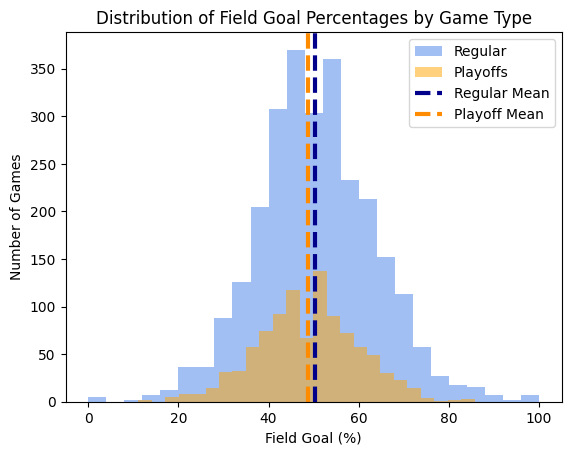

In [22]:
regular_fg = nba_clean[nba_clean["GameType"] == "Regular"]["FG%"].dropna()
playoff_fg = nba_clean[nba_clean["GameType"] == "Playoffs"]["FG%"].dropna()

regular_mean = regular_fg.mean()
playoff_mean = playoff_fg.mean()

plt.hist(
    regular_fg * 100,
    bins=25,
    alpha=0.6,
    label="Regular",
    color="cornflowerblue"
)

plt.hist(
    playoff_fg * 100,
    bins=25,
    alpha=0.5,
    label="Playoffs",
    color="orange"
)

plt.axvline(
    regular_mean * 100,
    color="darkblue",
    linestyle="--",
    linewidth=3,
    label="Regular Mean"
)

plt.axvline(
    playoff_mean * 100,
    color="darkorange",
    linestyle="--",
    linewidth=3,
    label="Playoff Mean"
)

plt.title("Distribution of Field Goal Percentages by Game Type")
plt.xlabel("Field Goal (%)")
plt.ylabel("Number of Games")
plt.legend()

plt.show()

## Graph 1:

The histogram compares the distribution of FG% between regular season and playoff games. The x-axis shows field goal percentage, and the y-axis shows the number of games that fall within each FG% range. Taller bars mean more games had FG% values in that range.

The dashed vertical lines represent the average FG% for each group. The dark blue line shows the regular season mean, while the dark orange line shows the playoff mean. The playoff mean is slightly lower, visually confirming the difference found in the descriptive statistics.

Both distributions overlap heavily, especially around the 40% to 60% FG% range. This means many regular season and playoff games had similar shooting percentages. If the groups were very different, the bars would be more separated, with one group mostly on one side and the other group on the other side.

The playoff distribution appears slightly more concentrated, while the regular season distribution is more spread out. This suggests that playoff FG% was somewhat more consistent from game to game, which matches the lower playoff standard deviation from the descriptive statistics.

Overall, the histogram does not show a dramatic difference between regular season and playoff FG%. It visually suggests that the two groups are mostly similar, even though playoff FG% is slightly lower on average.

## Average FG% by Player and Game Type

This graph compares each player's average FG% in regular season games and playoff games. This helps show whether the overall pattern is driven by one player or appears across multiple players.

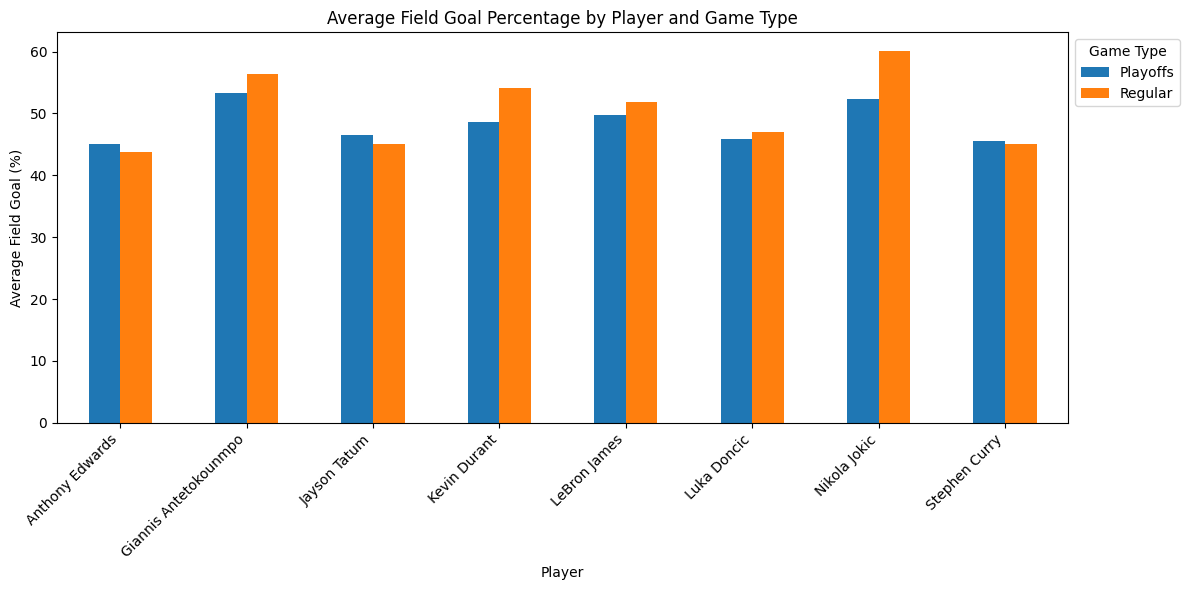

In [23]:
player_means = (
    nba_clean.groupby(["Player", "GameType"])["FG%"]
    .mean()
    .mul(100)
    .unstack()
)

player_means.plot(kind="bar", figsize=(12, 6))

plt.title("Average Field Goal Percentage by Player and Game Type")
plt.xlabel("Player")
plt.ylabel("Average Field Goal (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Game Type", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## Graph 2: 

This bar chart compares each player’s average FG% in regular season and playoff games. This helps show where the overall difference is coming from and whether the overall result is being driven by all players or only certain players.

The pattern is mixed across players. Anthony Edwards, Jayson Tatum, and Stephen Curry had slightly higher playoff FG% than regular season FG%, while Giannis Antetokounmpo, Kevin Durant, LeBron James, Luka Doncic, and Nikola Jokic had lower playoff FG% than regular season FG%. This shows that the overall playoff decrease is not caused by every player performing worse.

Instead, the difference appears to come from individual player variation. Some players improved slightly, while others declined. Because the pattern is not consistent across all players, a formal hypothesis test is needed to determine whether the overall difference is statistically meaningful or could have happened by random chance.

## Test Statistic

The test statistic used in this analysis is:

**Playoff FG% − Regular Season FG%**

A negative value means playoff FG% is lower than regular season FG%. A positive value means playoff FG% is higher than regular season FG%.

This value is used to measure the observed difference between the two groups before running the permutation test.

In [24]:
playoff_fg = nba_clean[nba_clean["GameType"] == "Playoffs"]["FG%"].dropna()
regular_fg = nba_clean[nba_clean["GameType"] == "Regular"]["FG%"].dropna()

observed_diff = playoff_fg.mean() - regular_fg.mean()

observed_diff

np.float64(-0.01590054777235006)

## Observed Difference:

The observed difference is approximately -0.016, meaning playoff FG% was about 1.6 percentage points lower than regular season FG% in this dataset. This tells what actually happened in the real data before running any simulations.

Since the value is negative, it shows that players shot slightly worse in the playoffs compared to the regular season. However, this difference is small, so it should not automatically be treated as proof that players truly perform worse in the playoffs.

The observed difference is used as the reference point for the permutation test. The permutation test compares this real difference to many simulated differences created under the assumption that there is no true difference between playoff and regular season FG%. This helps determine whether the observed drop is statistically meaningful or if it could have happened by random chance.

## Permutation Test

A permutation test is used to determine whether the observed difference in FG% could reasonably happen by random chance.

Under the null hypothesis, there is no true difference between playoff and regular season FG%. To simulate this, the FG% values are randomly shuffled and reassigned into playoff and regular season groups many times.

This creates a null distribution of simulated differences that would be expected if there were truly no real difference between playoff and regular season FG%.

In [25]:
combined = np.concatenate([playoff_fg, regular_fg])

n_playoff = len(playoff_fg)

num_simulations = 1000
simulated_diffs = []

for _ in range(num_simulations):
    shuffled = np.random.permutation(combined)
    
    sim_playoff = shuffled[:n_playoff]
    sim_regular = shuffled[n_playoff:]
    
    sim_diff = sim_playoff.mean() - sim_regular.mean()
    simulated_diffs.append(sim_diff)

simulated_diffs = np.array(simulated_diffs)

## Permutation Distribution for Mean Difference

The permutation distribution represents differences in FG% that could occur if there were truly no real difference between playoff and regular season performance. Each simulated difference was created by randomly shuffling the FG% values and reassigning them into new playoff and regular season groups.

The red line represents the actual observed difference from the dataset. In this graph, the observed difference falls toward the left side of the distribution, meaning the playoff FG% was lower than the regular season FG% in the real data.

However, the observed difference is still within the overall range of simulated differences generated under the null hypothesis. This means that a difference of this size could reasonably occur by random chance, which indicates the observed drop may not be statistically significant.

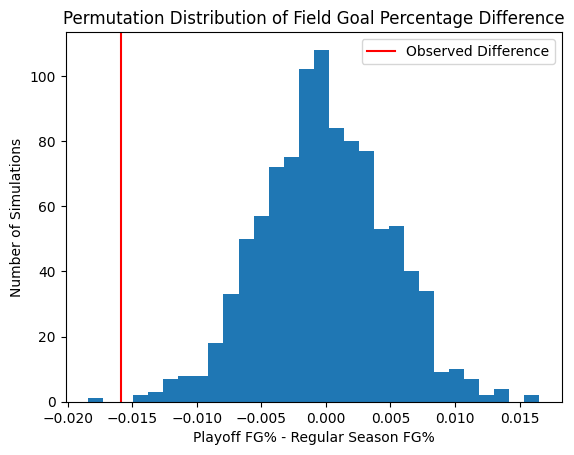

In [26]:
plt.hist(simulated_diffs, bins=30)

plt.axvline(observed_diff, color="red", label="Observed Difference")

plt.title("Permutation Distribution of Field Goal Percentage Difference")
plt.xlabel("Playoff FG% - Regular Season FG%")
plt.ylabel("Number of Simulations")

plt.legend()
plt.show()

## Graph 3:

This histogram shows the permutation distribution of simulated mean FG% differences under the null hypothesis. Each bar represents the number of simulations that produced a difference within that range after randomly shuffling the FG% values between playoff and regular season groups.

The distribution is centered near 0, which is expected under the null hypothesis because the simulations assume there is no true difference between playoff and regular season FG%. Most simulated differences are close to 0, while more extreme differences occur less often.

The red vertical line represents the observed difference from the real dataset, which was approximately -0.016. This value is far to the left of most simulated differences, meaning that very few random simulations produced a difference as extreme as the observed result.

This suggests that the observed decrease in playoff FG% is unlikely to have occurred purely by random chance. The permutation distribution therefore provides evidence against the null hypothesis and supports the idea that playoff FG% may truly be lower than regular season FG%.

## P-Value Calculation

The p-value represents the probability of observing a difference at least as extreme as the one found in the data, assuming the null hypothesis is true.

In [27]:
p_value = np.mean(simulated_diffs <= observed_diff)

p_value

np.float64(0.001)

In [28]:
extreme = simulated_diffs <= observed_diff

extreme_count = np.sum(extreme)

print("Extreme count:", extreme_count)
print("Total simulations:", len(simulated_diffs))
print("P-value:", extreme_count / len(simulated_diffs))

Extreme count: 1
Total simulations: 1000
P-value: 0.001


## P-Value

The permutation test produced a p-value of approximately 0.001. This means that only about 1 out of 1000 simulated differences was as extreme as the observed difference found in the real dataset, assuming the null hypothesis is true.

In this context, the null hypothesis means there is no true difference between playoff FG% and regular season FG% and any observed difference is just random variation.

Because the p-value is very small and well below a common significance level of 0.05, the observed difference is unlikely to have occurred purely by random chance.

Therefore, there is sufficient evidence to reject the null hypothesis. The results suggest that playoff FG% is statistically lower than regular season FG% in this dataset.

If there were truly no real playoff effect, there would only be about a 0.1% chance of randomly getting a difference as extreme as the one observed.

## Conclusion

Overall, the permutation test provides strong evidence against the null hypothesis. The observed difference was approximately -0.016, meaning playoff FG% was about 1.6 percentage points lower than regular season FG% in the real dataset.

The permutation distribution showed what differences would be expected if there were truly no real difference between playoff and regular season FG%. Most simulated differences were centered near 0, which makes sense because the null hypothesis assumes that any difference is only due to random variation.

The observed difference fell far into the left side of the permutation distribution. The p-value was approximately 0.001, meaning only about 1 out of 1000 simulations produced a difference as extreme as the observed result.

Since this p-value is much smaller than 0.05, the result is statistically significant. Therefore, there is enough evidence to reject the null hypothesis. Based on this analysis, playoff FG% appears to be statistically lower than regular season FG% for the players and seasons included in this dataset.

## Bootstrap Confidence Intervals

Bootstrapping is used to estimate uncertainty around the difference between playoff FG% and regular season FG%.

Instead of shuffling labels like the permutation test, bootstrapping resamples from the existing data with replacement. This creates many new sample datasets and helps estimate a range of likely values for the true FG% difference.

Two metrics are used:
- Mean FG% difference
- Median FG% difference

The median is included because the Central Limit Theorem does not apply to the median in the same direct way it applies to means.

In [29]:
num_bootstrap = 1000

mean_diffs = []
median_diffs = []

for _ in range(num_bootstrap):
    playoff_sample = np.random.choice(playoff_fg, size=len(playoff_fg), replace=True)
    regular_sample = np.random.choice(regular_fg, size=len(regular_fg), replace=True)
    
    mean_diffs.append(playoff_sample.mean() - regular_sample.mean())
    median_diffs.append(np.median(playoff_sample) - np.median(regular_sample))

mean_ci = np.percentile(mean_diffs, [2.5, 97.5])
median_ci = np.percentile(median_diffs, [2.5, 97.5])

mean_ci, median_ci

(array([-0.0243921 , -0.00800451]), array([-0.026,  0.   ]))

## Bootstrap Results

The bootstrap confidence intervals estimate the likely range of the true difference between playoff and regular season FG%.

If the interval includes 0, that means the difference could reasonably be no real difference.

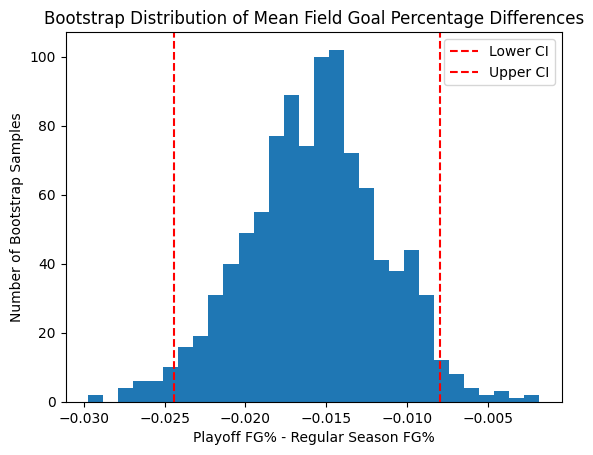

In [30]:
plt.hist(mean_diffs, bins=30)

plt.axvline(mean_ci[0], color="red", linestyle="--", label="Lower CI")
plt.axvline(mean_ci[1], color="red", linestyle="--", label="Upper CI")

plt.title("Bootstrap Distribution of Mean Field Goal Percentage Differences")
plt.xlabel("Playoff FG% - Regular Season FG%")
plt.ylabel("Number of Bootstrap Samples")

plt.legend()
plt.show()

## Graph 4: 

This histogram shows the bootstrap distribution of mean FG% differences. Each bootstrap sample was created by randomly resampling playoff and regular season games with replacement, then recalculating the mean difference.

The red dashed lines show the 95% bootstrap confidence interval. The interval ranges from approximately -0.0240 to -0.0071, meaning the true mean difference is likely between about 2.40 and 0.71 percentage points lower in the playoffs.

Because the entire interval is below 0, the bootstrap results suggest that playoff FG% is likely lower than regular season FG%. This supports the permutation test result and provides more evidence that the playoff decrease is not just random variation.

# Final Conclusion

This project investigated whether NBA star players perform worse in the playoffs compared to the regular season using field goal percentage (FG%) data.

The descriptive statistics and visualizations showed that playoff FG% was slightly lower on average than regular season FG%. The histograms also showed substantial overlap between the two distributions, although playoff FG% appeared somewhat more concentrated and consistent.

The permutation test was used to determine whether the observed difference could reasonably occur by random chance under the null hypothesis. The observed difference was approximately -0.016, meaning playoff FG% was about 1.6 percentage points lower than regular season FG%. The permutation test produced a p-value of approximately 0.001, indicating that such a difference would be very unlikely to occur if there were truly no real difference between playoff and regular season performance.

Bootstrap confidence intervals were then used to estimate a reasonable range for the true difference in FG%. The mean bootstrap confidence interval ranged from approximately -0.0246 to -0.0078. Because the entire interval was below 0, the bootstrap analysis supported the conclusion that playoff FG% is likely truly lower than regular season FG% for the players and seasons included in this dataset.

Overall, the results suggest that NBA star players in this dataset performed slightly worse in the playoffs in terms of shooting efficiency. Although the difference was not extremely large in magnitude, the statistical analysis suggests that the effect is likely real rather than purely random variation.